# Movies Data Analysis

## Project Overview
An exploratory analysis of a large-scale movie industry dataset (~1M titles, 1950–2025), built to answer four core questions for a studio/investment stakeholder audience:

1. How have production budgets, box-office revenue, ratings, and output volume trended over time?
2. Does spending more on a film's budget improve its return on investment (ROI)?
3. Which genres are the most profitable, and at what volume?
4. Which directors consistently deliver both high ratings and strong commercial results?

**Dataset note:** This dataset is synthetically generated (title/director/actor names are procedurally created rather than real) and is used here purely to demonstrate an end-to-end analytical workflow — data cleaning, feature engineering, correlation analysis, and insight generation — rather than to draw conclusions about the real film industry.


## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Data Loading

In [2]:
movie = pd.read_csv("movies_dataset.csv", index_col="MovieID")
movie.head()

,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
MovieID,,,,,,,,,,,,,,,,
1,Might toward capital,Comedy,2003,28-09-2003,China,"6,577,427.79","6,613,685.82","15,472,035.66","1,778,530.85","3,034,053.32",6.20,58,7865,10596,Kristina Moore,Brian Mccormick
2,He however experience,Comedy,1988,14-02-1988,USA,"1,883,810.10","1,930,949.15","3,637,731.12","247,115.74","831,828.84",5.20,44,1708,220,Benjamin Hudson,Ashley Pena
3,Star responsibility politics,Comedy,1971,02-11-1971,USA,"2,468,079.29","4,186,694.69","7,165,111.24","878,453.95","2,171,405.93",5.50,55,4678,7805,Kayla Young,Alexander Haley
4,Exactly live,Comedy,1998,06-08-1998,USA,"1,447,311.46","2,023,683.92","4,373,820.26","570,657.72","898,886.01",7.30,87,2467,1751,Michael Ross,Patrick Barnett
5,Focus improve especially,Documentary,2021,17-12-2021,India,"900,915.86","2,129,629.10","3,113,017.38","361,189.37","861,775.91",6.10,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [3]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999999 entries, 1 to 999999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Title                 999999 non-null  object 
 1   Genre                 999999 non-null  object 
 2   ReleaseYear           999999 non-null  int64  
 3   ReleaseDate           999999 non-null  object 
 4   Country               999999 non-null  object 
 5   BudgetUSD             999999 non-null  float64
 6   US_BoxOfficeUSD       999999 non-null  float64
 7   Global_BoxOfficeUSD   999999 non-null  float64
 8   Opening_Day_SalesUSD  999999 non-null  float64
 9   One_Week_SalesUSD     999999 non-null  float64
 10  IMDbRating            999999 non-null  float64
 11  RottenTomatoesScore   999999 non-null  int64  
 12  NumVotesIMDb          999999 non-null  int64  
 13  NumVotesRT            999999 non-null  int64  
 14  Director              999999 non-null  object 
 15  LeadA

## 3. Data Cleaning & Formatting

Before analysis, we check for missing values and confirm each column carries the correct data type.


In [4]:
# Check for rows containing any missing values
nan_df = movie[movie.isna().any(axis=1)]
print(f"Rows with at least one missing value: {len(nan_df)}")
nan_df.head()


Rows with at least one missing value: 0


,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
MovieID,,,,,,,,,,,,,,,,


In [5]:
# No missing values were found (0 rows above), so this drop is a defensive no-op
# that keeps the pipeline safe if the source data changes in the future.
movie = movie.dropna(how="all")
movie.head()


,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
MovieID,,,,,,,,,,,,,,,,
1,Might toward capital,Comedy,2003,28-09-2003,China,"6,577,427.79","6,613,685.82","15,472,035.66","1,778,530.85","3,034,053.32",6.20,58,7865,10596,Kristina Moore,Brian Mccormick
2,He however experience,Comedy,1988,14-02-1988,USA,"1,883,810.10","1,930,949.15","3,637,731.12","247,115.74","831,828.84",5.20,44,1708,220,Benjamin Hudson,Ashley Pena
3,Star responsibility politics,Comedy,1971,02-11-1971,USA,"2,468,079.29","4,186,694.69","7,165,111.24","878,453.95","2,171,405.93",5.50,55,4678,7805,Kayla Young,Alexander Haley
4,Exactly live,Comedy,1998,06-08-1998,USA,"1,447,311.46","2,023,683.92","4,373,820.26","570,657.72","898,886.01",7.30,87,2467,1751,Michael Ross,Patrick Barnett
5,Focus improve especially,Documentary,2021,17-12-2021,India,"900,915.86","2,129,629.10","3,113,017.38","361,189.37","861,775.91",6.10,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [6]:
movie["ReleaseDate"] = pd.to_datetime(movie["ReleaseDate"], format="%d-%m-%Y")
movie["Genre"] = movie["Genre"].astype("category")

movie.info()


<class 'pandas.core.frame.DataFrame'>
Index: 999999 entries, 1 to 999999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Title                 999999 non-null  object        
 1   Genre                 999999 non-null  category      
 2   ReleaseYear           999999 non-null  int64         
 3   ReleaseDate           999999 non-null  datetime64[ns]
 4   Country               999999 non-null  object        
 5   BudgetUSD             999999 non-null  float64       
 6   US_BoxOfficeUSD       999999 non-null  float64       
 7   Global_BoxOfficeUSD   999999 non-null  float64       
 8   Opening_Day_SalesUSD  999999 non-null  float64       
 9   One_Week_SalesUSD     999999 non-null  float64       
 10  IMDbRating            999999 non-null  float64       
 11  RottenTomatoesScore   999999 non-null  int64         
 12  NumVotesIMDb          999999 non-null  int64         
 13  NumV

In [7]:
movie.describe()

,ReleaseYear,ReleaseDate,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,"999,999.00",999999,"999,999.00","999,999.00","999,999.00","999,999.00","999,999.00","999,999.00","999,999.00","999,999.00","999,999.00"
mean,"1,998.00",1998-07-02 09:21:58.238518144,"9,802,823.55","14,961,631.98","27,206,253.68","2,992,745.17","7,483,442.02",6.49,64.78,"9,137.18","2,031.88"
min,"1,950.00",1950-01-01 00:00:00,"100,000.00","40,025.47","100,000.00","4,050.47","16,507.42",1.00,0.00,100.00,50.00
25%,"1,984.00",1984-08-17 00:00:00,"1,190,510.79","1,489,805.19","2,762,369.99","279,026.24","738,314.53",5.50,53.00,"1,083.00",119.00
50%,"2,001.00",2001-09-09 00:00:00,"3,265,789.51","4,388,875.59","8,090,223.36","838,722.12","2,179,436.34",6.50,65.00,"2,983.00",405.00
75%,"2,014.00",2014-11-20 00:00:00,"9,002,790.96","12,876,058.38","23,552,451.20","2,510,359.54","6,415,142.61",7.50,77.00,"8,192.00","1,360.00"
max,"2,025.00",2025-12-31 00:00:00,"300,000,000.00","1,018,197,889.00","1,499,496,720.00","295,751,068.20","579,555,113.20",10.00,100.00,"1,000,000.00","500,000.00"
std,19.26,NaN,"22,494,208.37","38,794,034.26","69,542,938.25","8,132,438.35","19,553,372.08",1.49,17.59,"24,922.36","8,433.38"


## 4. Feature Engineering

Two derived metrics are added to support the profitability analysis below:
- **Profit** = Global Box Office − Budget
- **ROI (%)** = Profit / Budget × 100


In [8]:
movie["Profit"] = movie["Global_BoxOfficeUSD"] - movie["BudgetUSD"]
movie["ROI"] = (movie["Profit"] / movie["BudgetUSD"]) * 100
movie.head()


,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,Profit,ROI
MovieID,,,,,,,,,,,,,,,,,,
1,Might toward capital,Comedy,2003,2003-09-28,China,"6,577,427.79","6,613,685.82","15,472,035.66","1,778,530.85","3,034,053.32",6.20,58,7865,10596,Kristina Moore,Brian Mccormick,"8,894,607.87",135.23
2,He however experience,Comedy,1988,1988-02-14,USA,"1,883,810.10","1,930,949.15","3,637,731.12","247,115.74","831,828.84",5.20,44,1708,220,Benjamin Hudson,Ashley Pena,"1,753,921.02",93.10
3,Star responsibility politics,Comedy,1971,1971-11-02,USA,"2,468,079.29","4,186,694.69","7,165,111.24","878,453.95","2,171,405.93",5.50,55,4678,7805,Kayla Young,Alexander Haley,"4,697,031.95",190.31
4,Exactly live,Comedy,1998,1998-08-06,USA,"1,447,311.46","2,023,683.92","4,373,820.26","570,657.72","898,886.01",7.30,87,2467,1751,Michael Ross,Patrick Barnett,"2,926,508.80",202.20
5,Focus improve especially,Documentary,2021,2021-12-17,India,"900,915.86","2,129,629.10","3,113,017.38","361,189.37","861,775.91",6.10,67,5555,697,Faith Franklin,Duane Fletcher DDS,"2,212,101.52",245.54


## 5. Question 1 — Trends in Budget, Box Office, Ratings, and Volume Over Time


In [9]:
yearly_trends = (
    movie.groupby("ReleaseYear")
    .agg(
        Avg_Budget=("BudgetUSD", "mean"),
        Avg_Global_BoxOffice=("Global_BoxOfficeUSD", "mean"),
        Avg_IMDbRating=("IMDbRating", "mean"),
        Movie_Count=("Title", "count"),
    )
    .reset_index()
)
yearly_trends.head()


,ReleaseYear,Avg_Budget,Avg_Global_BoxOffice,Avg_IMDbRating,Movie_Count
0,1950,"10,964,923.36","29,618,832.18",6.44,2432
1,1951,"9,993,369.23","27,725,749.88",6.55,2613
2,1952,"9,321,035.36","26,321,532.40",6.48,2960
3,1953,"9,377,751.08","26,654,460.77",6.49,3235
4,1954,"10,541,172.76","30,222,079.83",6.48,3496


In [10]:
yearly_trends.tail()

,ReleaseYear,Avg_Budget,Avg_Global_BoxOffice,Avg_IMDbRating,Movie_Count
71,2021,"9,802,317.37","27,266,733.90",6.49,22809
72,2022,"9,698,473.83","27,023,814.27",6.49,22812
73,2023,"10,049,713.88","28,015,540.42",6.50,23348
74,2024,"10,066,168.70","27,685,046.98",6.50,23492
75,2025,"9,886,061.34","27,211,154.23",6.51,23809


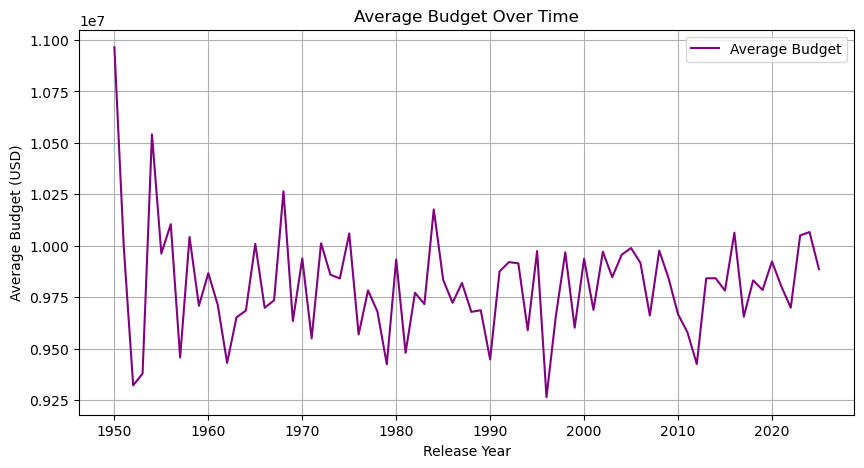

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_trends["ReleaseYear"], yearly_trends["Avg_Budget"], label="Average Budget", color="purple")
plt.title("Average Budget Over Time", color="black")
plt.xlabel("Release Year")
plt.ylabel("Average Budget (USD)")
plt.legend()
plt.grid()
plt.show()


**Insight:** Average budget per film held remarkably steady, hovering between $9.3M and $11.0M in both the 1950s and the 2020s — no meaningful long-run inflation or deflation in average production spend.

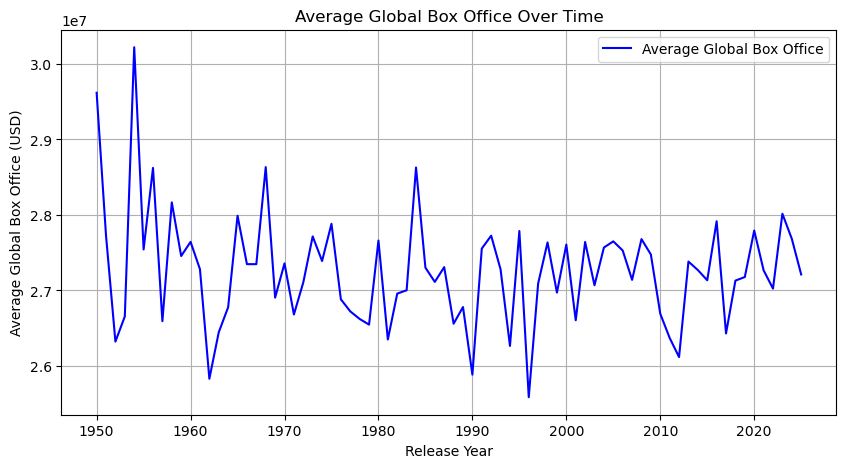

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_trends["ReleaseYear"], yearly_trends["Avg_Global_BoxOffice"], label="Average Global Box Office", color="blue")
plt.title("Average Global Box Office Over Time", color="black")
plt.xlabel("Release Year")
plt.ylabel("Average Global Box Office (USD)")
plt.legend()
plt.grid()
plt.show()


**Insight:** Global box-office earnings per film did not grow over time — averaging $29.6M in 1950 versus a nearly identical $27.2M in 2025, mirroring the flat budget trend above.

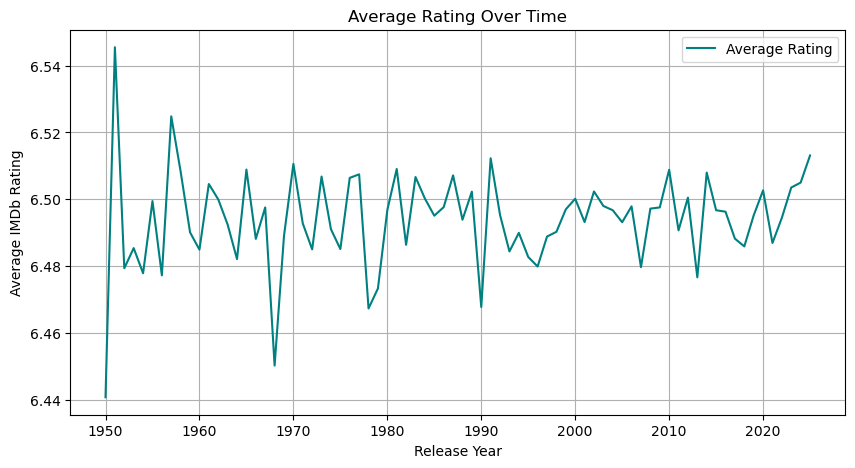

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_trends["ReleaseYear"], yearly_trends["Avg_IMDbRating"], label="Average Rating", color="teal")
plt.title("Average Rating Over Time", color="black")
plt.xlabel("Release Year")
plt.ylabel("Average IMDb Rating")
plt.legend()
plt.grid()
plt.show()


**Insight:** Average rating rose only marginally, from 6.44 in 1950 to a peak of 6.51 in 2025 — an exceptionally stable rating distribution that slowly tightened toward ~6.5 over 75 years.

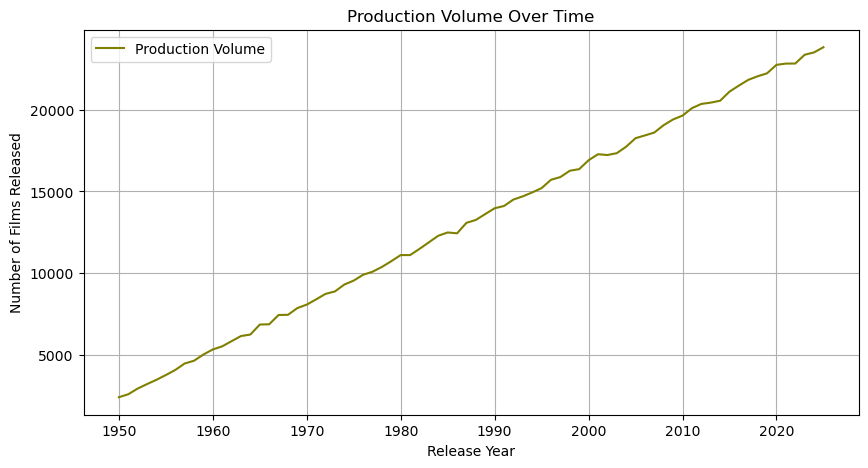

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_trends["ReleaseYear"], yearly_trends["Movie_Count"], label="Production Volume", color="olive")
plt.title("Production Volume Over Time", color="black")
plt.xlabel("Release Year")
plt.ylabel("Number of Films Released")
plt.legend()
plt.grid()
plt.show()


**Insight:** Unlike budget, revenue, and rating, production **volume** grew consistently year over year — from 2,432 films in 1950 to 23,809 in 2025, roughly a 10x increase — indicating that industry growth has come from output scale, not per-film economics.

## 6. Question 2 — Does a Bigger Budget Improve ROI?


In [15]:
corr_budget_revenue = movie["BudgetUSD"].corr(movie["Global_BoxOfficeUSD"])
corr_budget_revenue

np.float64(0.8954592841145066)

In [16]:
corr_budget_roi = movie["BudgetUSD"].corr(movie["ROI"])
corr_budget_roi

np.float64(-0.001083599187460948)

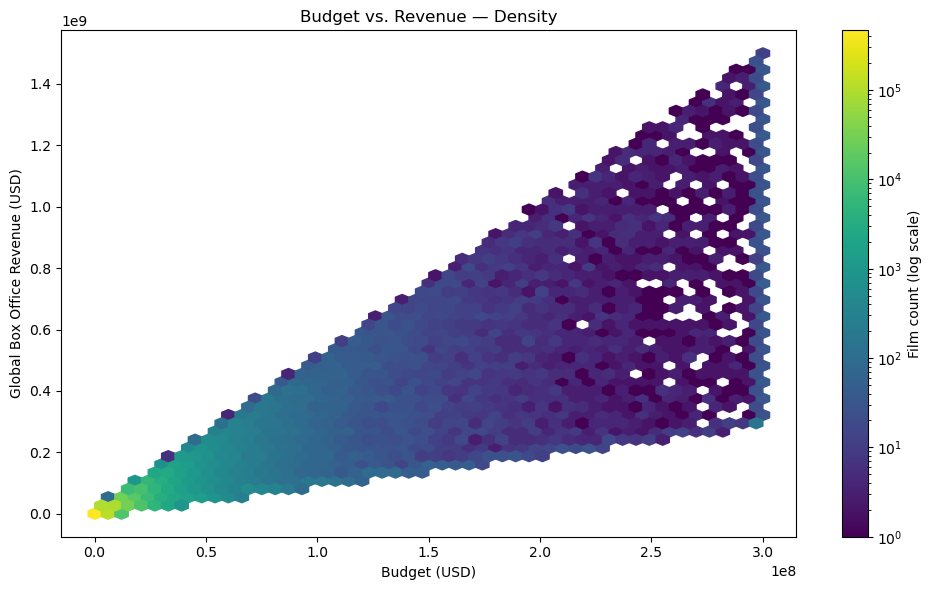

In [17]:
plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    movie["BudgetUSD"], movie["Global_BoxOfficeUSD"],
    gridsize=50, cmap="viridis", bins="log", mincnt=1
)
plt.colorbar(hb, label="Film count (log scale)")
plt.title("Budget vs. Revenue — Density", color="black")
plt.xlabel("Budget (USD)")
plt.ylabel("Global Box Office Revenue (USD)")
plt.tight_layout()
plt.show()


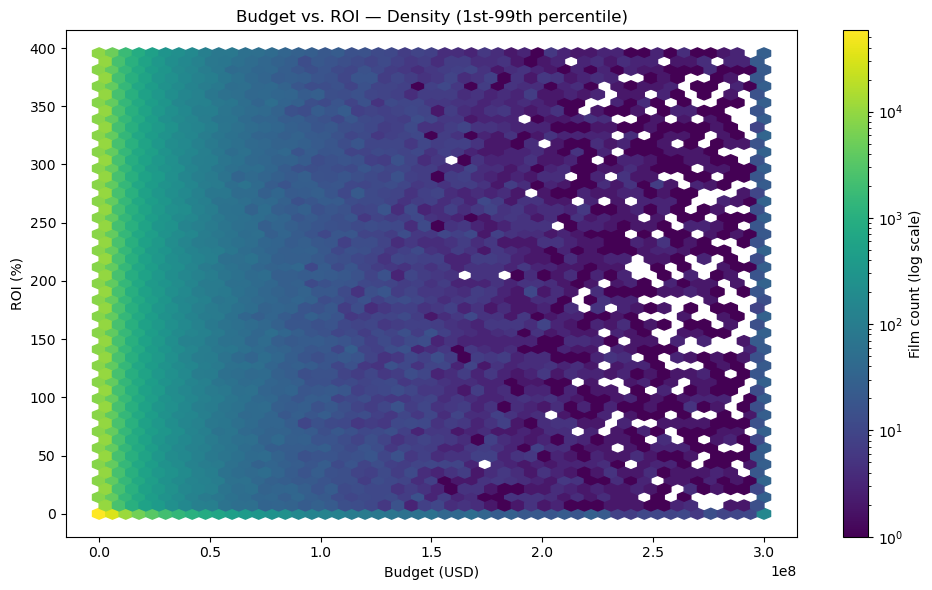

In [18]:
# ROI can carry extreme outliers for very low-budget films (small denominator).
# Clip to the 1st-99th percentile purely for VISUALIZATION so a handful of
# extreme values don't compress the rest of the chart into a flat line.
# (Correlation above was computed on the full, unclipped data.)
roi_low, roi_high = movie["ROI"].quantile([0.01, 0.99])

plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    movie["BudgetUSD"], movie["ROI"].clip(roi_low, roi_high),
    gridsize=50, cmap="viridis", bins="log", mincnt=1
)
plt.colorbar(hb, label="Film count (log scale)")
plt.title("Budget vs. ROI — Density (1st-99th percentile)", color="black")
plt.xlabel("Budget (USD)")
plt.ylabel("ROI (%)")
plt.tight_layout()
plt.show()


**Insight:** Budget has a strong positive correlation with absolute revenue (**r = 0.90**) — bigger films do earn more in absolute dollar terms. However, the correlation between budget and **ROI** is effectively zero (**r = -0.001**), meaning higher spending does not translate into better investment efficiency. In other words: bigger budgets buy bigger box-office totals, but not better returns per dollar spent.

## 7. Question 3 — Which Genres Are Most Popular and Profitable?


In [19]:
movie["Genre"] = movie["Genre"].str.split("|")
movie["Genre"].head()

MovieID
1         [Comedy]
2         [Comedy]
3         [Comedy]
4         [Comedy]
5    [Documentary]
Name: Genre, dtype: object

In [20]:
genre = (
    movie.explode("Genre")
    .groupby("Genre")
    .agg(
        Total_Profit=("Profit", "sum"),
        Avg_IMDbRating=("IMDbRating", "mean"),
        Movie_Count=("Title", "count"),
    )
    .sort_values("Total_Profit", ascending=False)
)
genre


,Total_Profit,Avg_IMDbRating,Movie_Count
Genre,,,
Drama,"4,339,877,850,088.78",6.49,250018
Comedy,"3,475,759,528,406.78",6.50,199832
Action,"2,586,474,897,070.04",6.50,150131
Horror,"1,760,306,836,988.22",6.50,100010
Thriller,"1,755,927,619,972.16",6.50,100071
Romance,"1,744,260,263,847.95",6.49,100021
Documentary,"884,545,741,627.83",6.50,50114
Sci-Fi,"856,259,989,555.76",6.50,49802


### Genre Profitability — Visualized

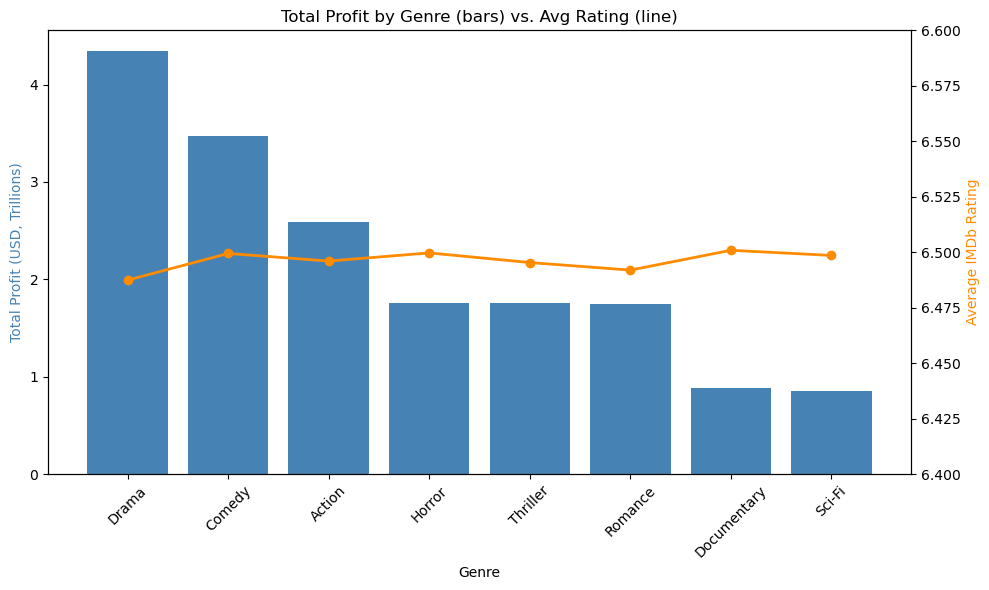

In [21]:
top_genres = genre.sort_values("Total_Profit", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(top_genres.index, top_genres["Total_Profit"] / 1e12, color="steelblue")
ax1.set_ylabel("Total Profit (USD, Trillions)", color="steelblue")
ax1.set_xlabel("Genre")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Total Profit by Genre (bars) vs. Avg Rating (line)", color="black")

ax2 = ax1.twinx()
ax2.plot(top_genres.index, top_genres["Avg_IMDbRating"], color="darkorange", marker="o", linewidth=2)
ax2.set_ylabel("Average IMDb Rating", color="darkorange")
ax2.set_ylim(6.4, 6.6) 

fig.tight_layout()
plt.show()


**Insight:** Drama leads on both volume and total profit, generating roughly $4.34 trillion in cumulative profit across 250,018 titles — more a function of sheer output volume than superior per-film economics, since average ratings are nearly flat (~6.49–6.50) across every genre.

## 8. Question 4 — Which Directors Deliver Consistently High Ratings *and* Commercial Success?

To avoid rewarding one-hit outliers, directors are first filtered to those with more than 3 films before ranking by average rating.


In [22]:
director = (
    movie.groupby("Director")
    .agg(
        Movie_Count=("Title", "count"),
        Avg_Rating=("IMDbRating", "mean"),
        Avg_Profit=("Profit", "mean"),
        Total_Global_BoxOffice=("Global_BoxOfficeUSD", "sum"),
    )
    .sort_values("Total_Global_BoxOffice", ascending=False)
)
director.head()


,Movie_Count,Avg_Rating,Avg_Profit,Total_Global_BoxOffice
Director,,,,
Judy Walker,6658,6.46,"18,877,281.60","194,740,416,291.05"
Albert Phillips,6634,6.48,"18,864,968.26","194,476,114,920.58"
Emily Miller,6776,6.52,"18,406,540.70","193,126,366,895.10"
William Walker,6758,6.50,"18,346,796.76","192,378,455,764.99"
Brooke Morales,6750,6.49,"18,478,372.87","191,935,444,167.68"


In [23]:
min_movies = 3
qualified_directors = director[director["Movie_Count"] > min_movies]
qualified_directors.head()


,Movie_Count,Avg_Rating,Avg_Profit,Total_Global_BoxOffice
Director,,,,
Judy Walker,6658,6.46,"18,877,281.60","194,740,416,291.05"
Albert Phillips,6634,6.48,"18,864,968.26","194,476,114,920.58"
Emily Miller,6776,6.52,"18,406,540.70","193,126,366,895.10"
William Walker,6758,6.50,"18,346,796.76","192,378,455,764.99"
Brooke Morales,6750,6.49,"18,478,372.87","191,935,444,167.68"


In [24]:
best_directors = qualified_directors.sort_values(by="Avg_Rating", ascending=False)
best_directors.head(10)


,Movie_Count,Avg_Rating,Avg_Profit,Total_Global_BoxOffice
Director,,,,
Carolyn Schwartz,6722,6.54,"17,395,277.31","183,658,221,945.90"
Mrs. Hannah Campbell DDS,6484,6.54,"17,459,724.81","176,202,194,351.87"
James Miller,6677,6.54,"17,357,382.55","181,822,382,923.67"
Chad Koch,6574,6.53,"17,098,921.50","176,027,632,268.77"
Roberto Underwood,6603,6.52,"17,008,379.22","174,323,394,805.07"
Ashley Medina,6667,6.52,"17,671,611.56","186,860,152,835.81"
Donna Wagner,6602,6.52,"17,982,343.52","183,453,013,275.35"
Seth Whitehead,6569,6.52,"17,438,334.60","178,054,675,133.30"
Jeffrey Neal,6674,6.52,"16,875,819.00","176,606,123,786.27"


### Top Directors — Visualized

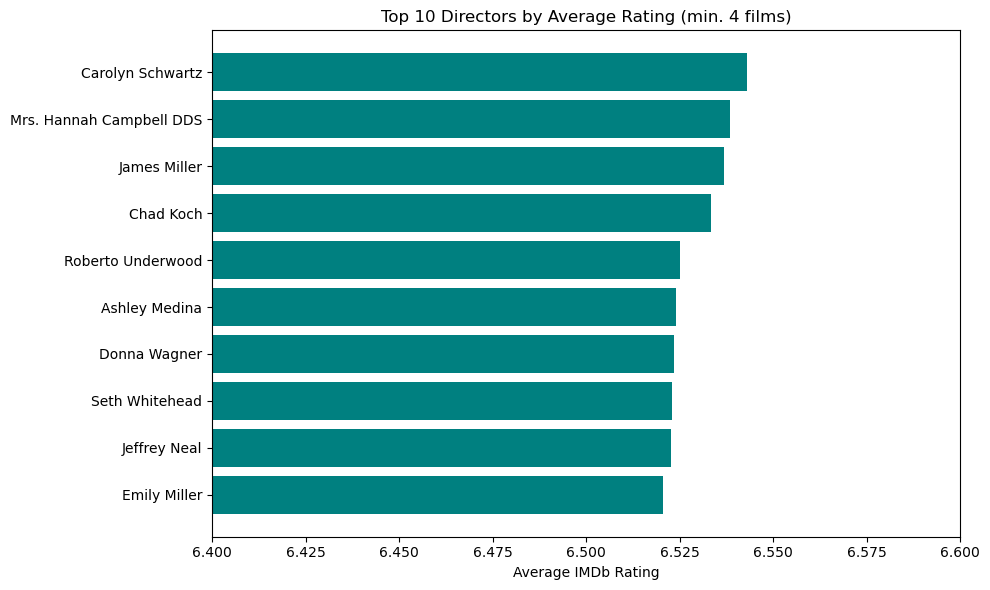

In [25]:
top10 = best_directors.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index[::-1], top10["Avg_Rating"][::-1], color="teal")
plt.xlim(6.4, 6.6)
plt.xlabel("Average IMDb Rating")
plt.title("Top 10 Directors by Average Rating (min. 4 films)", color="black")
plt.tight_layout()
plt.show()


**Insight:** Among directors with a qualifying track record (4+ films), Carolyn Schwartz and Mrs. Hannah Campbell DDS lead on quality control, holding the highest average ratings (6.54 and 6.53 respectively) — narrowly ahead of the field, reflecting the dataset's tightly clustered rating distribution noted in Section 5.

## 9. Executive Summary

| Question | Finding |
|---|---|
| Trends over time | Per-film budget, revenue, and ratings have stayed flat since 1950; industry growth has come entirely from **volume** (~10x more films released by 2025) |
| Budget vs. ROI | Budget strongly predicts absolute revenue (r = 0.90) but has **no relationship with ROI** (r = -0.001) — bigger budgets don't buy better returns |
| Genre profitability | **Drama** is the top genre by total profit and volume, but this reflects output scale rather than superior per-film performance — ratings are nearly flat across all genres |
| Director performance | A small group of directors with 4+ films sustain above-average ratings (~6.5+), but the overall rating spread across directors is narrow |

**Takeaway for stakeholders:** In this dataset, scale (more films, bigger budgets) drives absolute totals, but does not meaningfully improve per-film quality or capital efficiency. Investment strategy should weigh **ROI-efficient production** over simply increasing budget size, and genre/director selection should be evaluated on consistency across a larger sample rather than single standout results.
